# HR Analytics — Employee Promotion Prediction

**Problem type:** Binary Classification  
**Target column:** `is_promoted`  (1 = the employee was promoted, 0 = not promoted)

This notebook is built step by step. This version covers **Step 1 (Project Understanding)** and **Step 2 (Data Cleaning)**.

## Step 1 — Project Understanding

### Business problem
A large multinational company wants to know **in advance which employees deserve a promotion**.
Today the promotion process is slow and manual, and it can be affected by manager bias.
If we can predict who is likely to be promoted, the HR department can prepare those people
in time and make the process faster and fairer.

### The question we are answering
**Main question:** Can we predict whether an employee will be promoted, using their
performance and profile data?

We will also explore these supporting questions during the analysis (EDA):
1. Does a higher average training score increase the chance of promotion?
2. Are employees who won an award more likely to be promoted?
3. Does the department or region change the promotion rate?
4. Does age or length of service relate to promotion?
5. Does the previous year rating relate to promotion?
6. How balanced is the data between promoted and not promoted employees?

### Dataset description (and proof that it is NOT clean)
- **Source:** HR Analytics dataset (Analytics Vidhya "WNS" Hackathon 2018), downloaded from Kaggle.
  This dataset is **not** part of the Epsilon recommended datasets list.
- **Size:** 54,808 rows and 13 columns — a mix of numeric and categorical data.
- **The data is dirty and needs cleaning:**
  - `education` has **2,409 missing values**.
  - `previous_year_rating` has **4,124 missing values**.
  - The column `awards_won?` has a question mark in its name (hard to use in code).
  - `employee_id` is just an ID number with no predictive value.
  - **Duplicate rows** appear once the ID column is removed.
- **The target is imbalanced:** only about **8.5%** of employees were promoted.
  Because of this, we will judge the models using **precision and recall**, not accuracy,
  and we will handle the imbalance later in the modeling step.

### Column dictionary
| Column | Meaning |
|---|---|
| `employee_id` | Unique ID for each employee (dropped, not a feature) |
| `department` | Department of the employee |
| `region` | Region of employment |
| `education` | Education level |
| `gender` | Gender of the employee |
| `recruitment_channel` | How the employee was hired |
| `no_of_trainings` | Number of trainings completed last year |
| `age` | Age of the employee |
| `previous_year_rating` | Performance rating from last year (1 to 5) |
| `length_of_service` | Years the employee has worked at the company |
| `awards_won?` | 1 if the employee won an award last year, else 0 |
| `avg_training_score` | Average score in training evaluations |
| `is_promoted` | **Target** — 1 if promoted, 0 if not |

## Step 2 — Data Cleaning

In this step we will:
1. Load the data and look at its shape, types, and missing values.
2. Drop the `employee_id` column (it is only an identifier).
3. Rename `awards_won?` to `awards_won` to remove the special character.
4. Fill the missing values in `education` (with the most common value).
5. Fill the missing values in `previous_year_rating` (with the median value).
6. Drop duplicate rows.
7. Confirm that there are no missing values left.
8. Compare the shape **before** and **after** cleaning.

In [1]:
# Import the pandas library for working with tables of data
import pandas as pd

In [2]:
# Load the raw dataset from the CSV file
raw_df = pd.read_csv("train.csv")

# Show the number of rows and columns BEFORE cleaning
print("Shape BEFORE cleaning:", raw_df.shape)

Shape BEFORE cleaning: (54808, 13)


In [3]:
# Look at the first 5 rows to understand what the data looks like
raw_df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [4]:
# Show the column names, their data types, and how many non-null values each has
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


In [5]:
# Count how many missing values are in each column
print(raw_df.isnull().sum())

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64


In [6]:
# Look at the target: how many employees were promoted (1) vs not promoted (0)
print(raw_df["is_promoted"].value_counts())
print()
# Show the same thing as percentages to see the imbalance clearly
print(raw_df["is_promoted"].value_counts(normalize=True) * 100)

is_promoted
0    50140
1     4668
Name: count, dtype: int64

is_promoted
0    91.482995
1     8.517005
Name: proportion, dtype: float64


### Applying the cleaning steps
We work on a copy called `clean_df` so the original `raw_df` stays safe.

In [7]:
# Make a copy of the raw data so we keep the original data safe
clean_df = raw_df.copy()

In [8]:
# Drop the employee_id column because it is only an identifier, not a useful feature
clean_df = clean_df.drop(columns=["employee_id"])

# Rename the 'awards_won?' column to remove the question mark and make it easier to use
clean_df = clean_df.rename(columns={"awards_won?": "awards_won"})

In [9]:
# Fill the missing values in 'education' with the most common education level (the mode)
education_mode = clean_df["education"].mode()[0]
clean_df["education"] = clean_df["education"].fillna(education_mode)
print("Missing 'education' values were filled with:", education_mode)

Missing 'education' values were filled with: Bachelor's


In [10]:
# Fill the missing values in 'previous_year_rating' with the median rating.
# We use the median because this column is numeric and the median is not affected by extreme values.
rating_median = clean_df["previous_year_rating"].median()
clean_df["previous_year_rating"] = clean_df["previous_year_rating"].fillna(rating_median)
print("Missing 'previous_year_rating' values were filled with:", rating_median)

Missing 'previous_year_rating' values were filled with: 3.0


In [11]:
# Remove duplicate rows (employees that have exactly the same values in every column)
clean_df = clean_df.drop_duplicates()

# Reset the row numbers so the index is clean and continuous again
clean_df = clean_df.reset_index(drop=True)

In [12]:
# Confirm there are no missing values left in any column
print(clean_df.isnull().sum())

department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won              0
avg_training_score      0
is_promoted             0
dtype: int64


In [13]:
# Show the number of rows and columns AFTER cleaning
print("Shape AFTER cleaning:", clean_df.shape)

Shape AFTER cleaning: (54517, 12)


### Cleaning summary
- Started with **54,808 rows × 13 columns**.
- Dropped `employee_id` → 12 columns.
- Filled **2,409** missing values in `education` and **4,124** missing values in `previous_year_rating`.
- Removed duplicate rows (291 rows).
- Result: **54,517 rows × 12 columns** with **0 missing values**, ready for analysis.

**Next step → Step 3: Exploratory Data Analysis (EDA).**

## Step 3 — Exploratory Data Analysis (EDA)

Here we explore the data from many angles to understand what drives promotion.
We use **univariate** analysis (one variable at a time) and **bivariate** analysis
(a variable compared against the target `is_promoted`), with several kinds of plots
and statistical summaries.

In [14]:
# Import the libraries we need for plotting and for the statistical test
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Make the plots appear inside the notebook and use a clean style
%matplotlib inline
sns.set_style("whitegrid")

### Univariate analysis (one variable at a time)

In [15]:
# Statistical summary (count, mean, min, max, etc.) for the numeric columns
clean_df.describe()

,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
count,54517.000000,54517.000000,54517.000000,54517.000000,54517.000000,54517.000000,54517.00000
mean,1.253737,34.835336,3.305226,5.881065,0.023295,63.411761,0.08557
std,0.610085,7.660407,1.216125,4.266278,0.150842,13.374278,0.27973
min,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.00000
25%,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.00000
50%,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.00000
75%,1.000000,39.000000,4.000000,7.000000,0.000000,76.000000,0.00000
max,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.00000


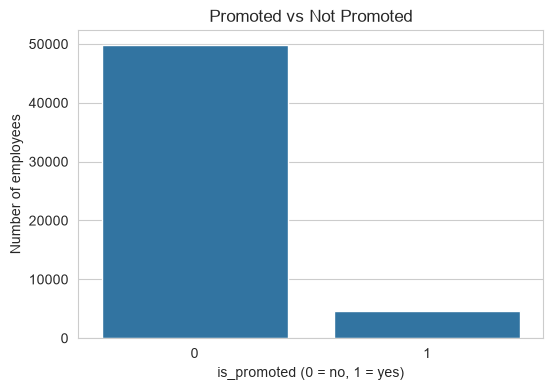

In [16]:
# Plot (univariate): how many employees were promoted (1) vs not promoted (0)
plt.figure(figsize=(6, 4))
sns.countplot(data=clean_df, x="is_promoted")
plt.title("Promoted vs Not Promoted")
plt.xlabel("is_promoted (0 = no, 1 = yes)")
plt.ylabel("Number of employees")
plt.show()

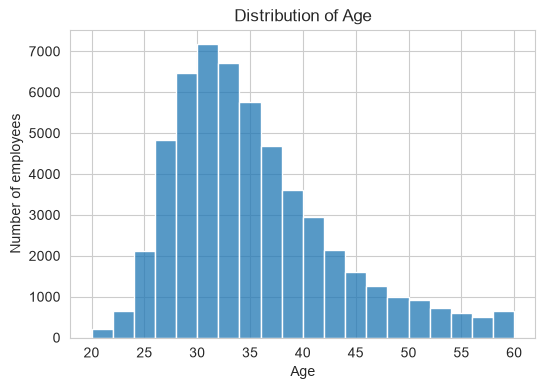

In [17]:
# Plot (univariate): distribution of employee age
plt.figure(figsize=(6, 4))
sns.histplot(data=clean_df, x="age", bins=20)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of employees")
plt.show()

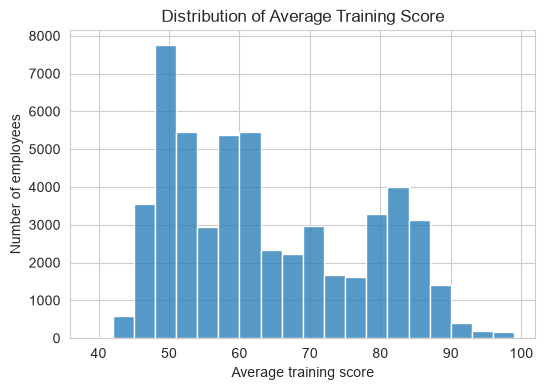

In [18]:
# Plot (univariate): distribution of the average training score
plt.figure(figsize=(6, 4))
sns.histplot(data=clean_df, x="avg_training_score", bins=20)
plt.title("Distribution of Average Training Score")
plt.xlabel("Average training score")
plt.ylabel("Number of employees")
plt.show()

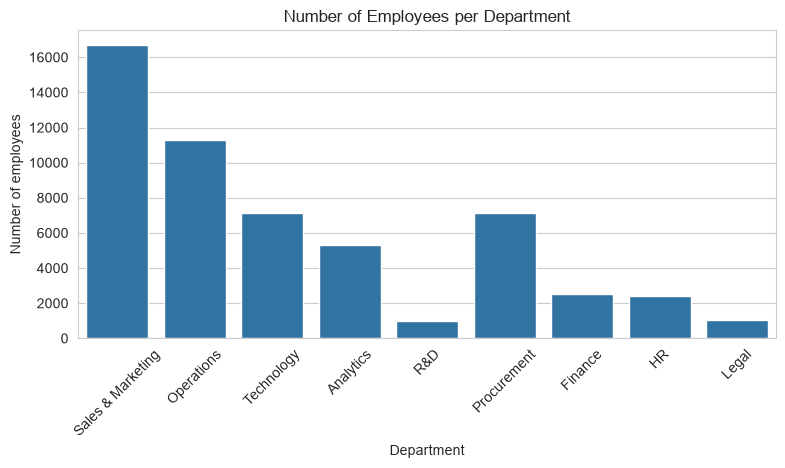

In [19]:
# Plot (univariate): number of employees in each department
plt.figure(figsize=(9, 4))
sns.countplot(data=clean_df, x="department")
plt.title("Number of Employees per Department")
plt.xlabel("Department")
plt.ylabel("Number of employees")
plt.xticks(rotation=45)
plt.show()

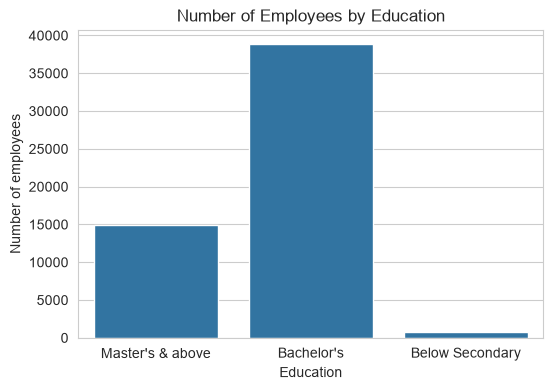

In [20]:
# Plot (univariate): number of employees by education level
plt.figure(figsize=(6, 4))
sns.countplot(data=clean_df, x="education")
plt.title("Number of Employees by Education")
plt.xlabel("Education")
plt.ylabel("Number of employees")
plt.show()

### Bivariate analysis (each variable vs the target `is_promoted`)

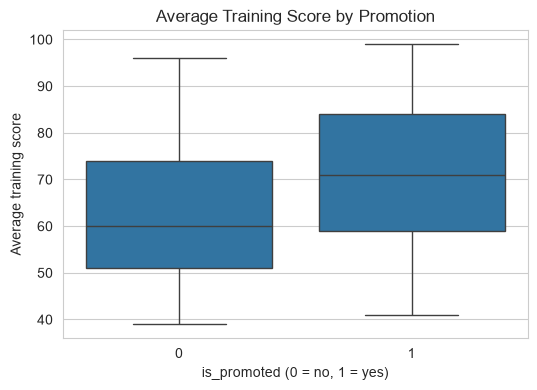

In [21]:
# Plot (bivariate): training score for promoted vs not promoted employees
plt.figure(figsize=(6, 4))
sns.boxplot(data=clean_df, x="is_promoted", y="avg_training_score")
plt.title("Average Training Score by Promotion")
plt.xlabel("is_promoted (0 = no, 1 = yes)")
plt.ylabel("Average training score")
plt.show()

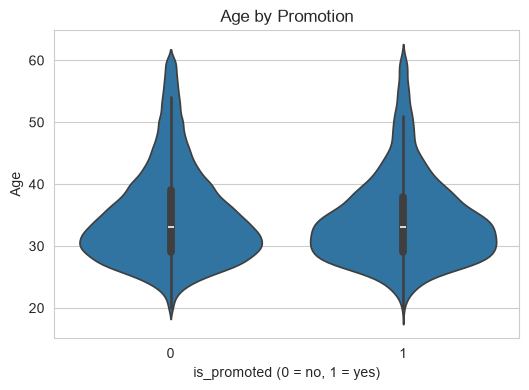

In [22]:
# Plot (bivariate): age for promoted vs not promoted employees
plt.figure(figsize=(6, 4))
sns.violinplot(data=clean_df, x="is_promoted", y="age")
plt.title("Age by Promotion")
plt.xlabel("is_promoted (0 = no, 1 = yes)")
plt.ylabel("Age")
plt.show()

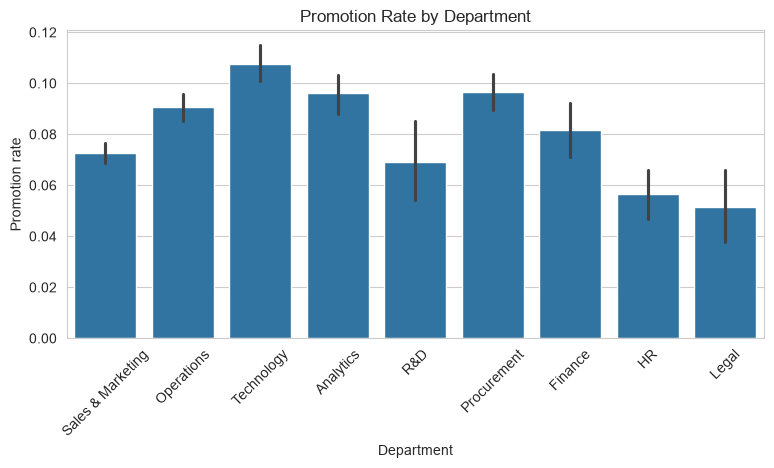

In [23]:
# Plot (bivariate): promotion rate for each department
# (seaborn shows the average of is_promoted, which equals the promotion rate)
plt.figure(figsize=(9, 4))
sns.barplot(data=clean_df, x="department", y="is_promoted")
plt.title("Promotion Rate by Department")
plt.xlabel("Department")
plt.ylabel("Promotion rate")
plt.xticks(rotation=45)
plt.show()

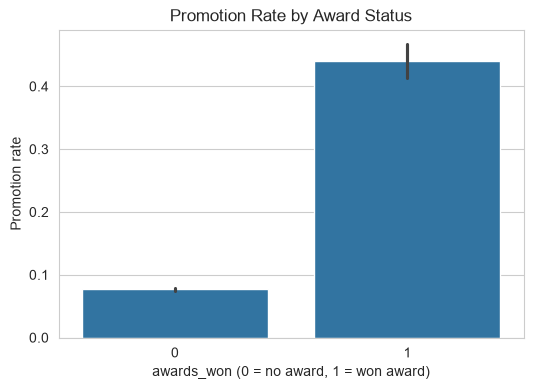

In [24]:
# Plot (bivariate): promotion rate for employees who won an award vs those who did not
plt.figure(figsize=(6, 4))
sns.barplot(data=clean_df, x="awards_won", y="is_promoted")
plt.title("Promotion Rate by Award Status")
plt.xlabel("awards_won (0 = no award, 1 = won award)")
plt.ylabel("Promotion rate")
plt.show()

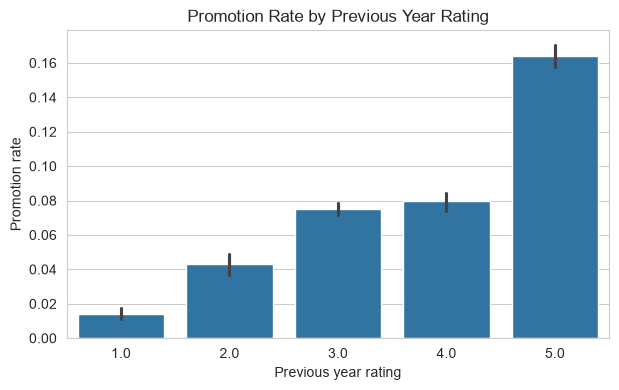

In [25]:
# Plot (bivariate): promotion rate for each previous year rating
plt.figure(figsize=(7, 4))
sns.barplot(data=clean_df, x="previous_year_rating", y="is_promoted")
plt.title("Promotion Rate by Previous Year Rating")
plt.xlabel("Previous year rating")
plt.ylabel("Promotion rate")
plt.show()

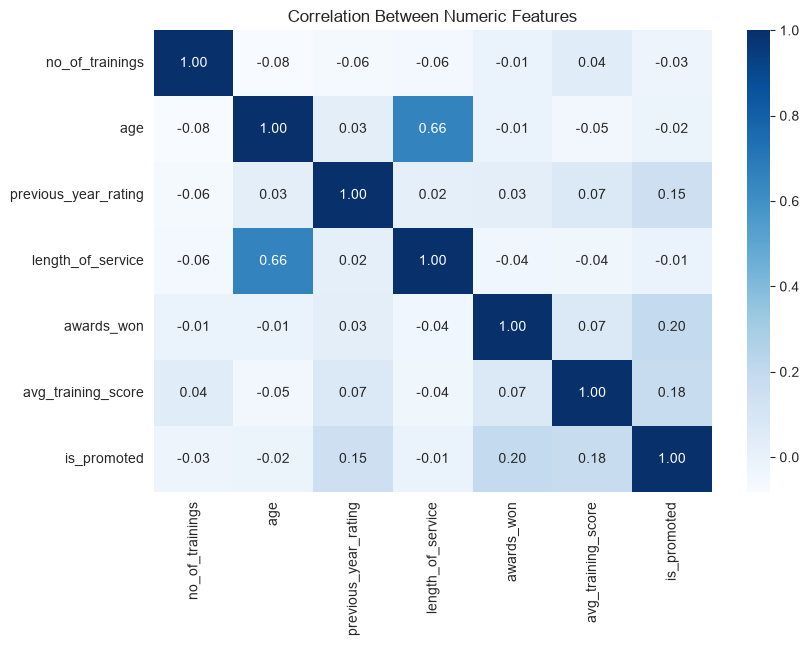

In [26]:
# Plot (bivariate): correlation between all numeric columns
numeric_columns = ["no_of_trainings", "age", "previous_year_rating",
                   "length_of_service", "awards_won", "avg_training_score", "is_promoted"]
plt.figure(figsize=(9, 6))
sns.heatmap(clean_df[numeric_columns].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.show()

### Statistical test (t-test)
We check whether promoted employees really have a different average training score,
instead of guessing from the plot only.

In [27]:
# Split the training scores into two groups: promoted and not promoted
promoted_scores = clean_df[clean_df["is_promoted"] == 1]["avg_training_score"]
not_promoted_scores = clean_df[clean_df["is_promoted"] == 0]["avg_training_score"]

# Run an independent t-test to compare the two groups
t_stat, p_value = ttest_ind(promoted_scores, not_promoted_scores)
print("Mean score (promoted):", round(promoted_scores.mean(), 2))
print("Mean score (not promoted):", round(not_promoted_scores.mean(), 2))
print("t-statistic:", round(t_stat, 2))
print("p-value:", p_value)

Mean score (promoted): 71.32
Mean score (not promoted): 62.67
t-statistic: 42.96
p-value: 0.0


### Step 3 — Key findings (EDA summary)
- **Imbalanced target:** only about **8.6%** of employees were promoted, so accuracy alone would be misleading — we will rely on **precision and recall**.
- **Awards matter the most:** employees who won an award have a **~44%** promotion rate, vs only **~8%** for those who did not.
- **Training score matters:** promoted employees have a higher average score (about **71** vs **63**). The t-test p-value is far below 0.05, so this difference is **statistically significant**.
- **Previous year rating matters:** the promotion rate rises with the rating — from about **1.4%** at rating 1 to about **16%** at rating 5.
- **Department has some effect:** Technology, Procurement and Analytics have the highest promotion rates; Legal and HR the lowest.
- **Weak signals:** `age`, `length_of_service` and `no_of_trainings` have almost no correlation with promotion.

The strongest signals are **`awards_won`, `avg_training_score` and `previous_year_rating`** — this guides the next step.

**Next step → Step 4: Feature Engineering.**

## Step 4 — Feature Engineering

We create new features from the existing columns to give the models stronger signals.
From the EDA, the strongest signals were the **training score** and the **previous year rating**,
so we build new features from them.

We add two new features:
1. **`total_score`** = `avg_training_score` × `previous_year_rating` — a single "overall performance"
   number that combines two strong signals. It has a higher correlation with promotion
   (about **0.23**) than either column alone.
2. **`high_training_score`** — a simple flag: `1` if the average training score is 80 or above,
   otherwise `0`. Employees in this group are promoted about **16%** of the time, vs about **7%**
   for the rest.

In [28]:
# Create a new feature: overall performance = training score multiplied by previous year rating
clean_df["total_score"] = clean_df["avg_training_score"] * clean_df["previous_year_rating"]

In [29]:
# Create a new feature: a flag that is 1 when the training score is high (80 or above), otherwise 0
clean_df["high_training_score"] = (clean_df["avg_training_score"] >= 80).astype(int)

In [30]:
# Show the two new columns next to the columns they were built from
clean_df[["avg_training_score", "previous_year_rating", "total_score", "high_training_score"]].head()

,avg_training_score,previous_year_rating,total_score,high_training_score
0,49,5.0,245.0,0
1,60,5.0,300.0,0
2,50,3.0,150.0,0
3,50,1.0,50.0,0
4,73,3.0,219.0,0


In [31]:
# Check that the new features are actually useful

# 1) Correlation of the new total_score with the target
print("Correlation of total_score with is_promoted:", round(clean_df["total_score"].corr(clean_df["is_promoted"]), 3))

# 2) Promotion rate (%) for high scorers vs normal scorers
print(clean_df.groupby("high_training_score")["is_promoted"].mean() * 100)

Correlation of total_score with is_promoted: 0.23
high_training_score
0     6.670603
1    16.475973
Name: is_promoted, dtype: float64


### Step 4 — Summary
- Added **	otal_score** (training score × rating) — more predictive than either column alone.
- Added **high_training_score** (flag for top scorers) — this group is promoted far more often.

The dataset now has these extra features, ready for feature selection and modeling.

**Next step → Step 5: Feature Selection (Embedded method — Random Forest importance).**

## Step 5 — Feature Selection

Before selecting features, we must turn the text (categorical) columns into numbers.
Then we apply the **Embedded** feature selection method (Random Forest feature importance)
and use its results to choose the final feature set.

In [32]:
# Import the tool we need for the embedded feature selection method
from sklearn.ensemble import RandomForestClassifier

In [33]:
# Convert the text (categorical) columns into 0/1 numeric columns using one-hot encoding.
# drop_first=True removes one redundant column per category.
categorical_columns = ["department", "region", "education", "gender", "recruitment_channel"]
model_df = pd.get_dummies(clean_df, columns=categorical_columns, drop_first=True)

# Separate the target (y) from the features (X)
y = model_df["is_promoted"]
X = model_df.drop(columns=["is_promoted"])

print("Number of features after encoding:", X.shape[1])

Number of features after encoding: 54


### Embedded method — Random Forest importance
A Random Forest gives each feature an importance score while it trains.

In [34]:
# Embedded method: a Random Forest gives an importance score to each feature while training
forest_for_selection = RandomForestClassifier(n_estimators=100, random_state=42)
forest_for_selection.fit(X, y)

# Put the importances in a Series and sort them from highest to lowest
forest_importances = pd.Series(forest_for_selection.feature_importances_, index=X.columns)
forest_importances = forest_importances.sort_values(ascending=False)
print("Top 15 features by Random Forest importance:")
print(forest_importances.head(15).round(4))

Top 15 features by Random Forest importance:
avg_training_score              0.1896
total_score                     0.1473
age                             0.1427
length_of_service               0.1172
previous_year_rating            0.0314
recruitment_channel_sourcing    0.0311
department_Sales & Marketing    0.0295
awards_won                      0.0271
department_Operations           0.0262
gender_m                        0.0250
no_of_trainings                 0.0225
department_Procurement          0.0224
education_Master's & above      0.0161
high_training_score             0.0129
region_region_2                 0.0116
dtype: float64


### Final decision
Based on the Random Forest importance scores, the strongest features are the **training score**,
our engineered ****, the **previous year rating**, **awards**, **age** and
**length of service**.

The  column has **34 sparse categories**, and each of its dummy columns has a very low
importance score, so we drop it to keep the model and the deployment app simpler. We keep all
the other features.

In [35]:
# Find all the region dummy columns (they all start with "region_")
region_columns = [col for col in model_df.columns if col.startswith("region_")]

# Build the final feature set: drop the target and the region columns
X_selected = model_df.drop(columns=["is_promoted"] + region_columns)

print("Final number of features:", X_selected.shape[1])
print("Final features:")
print(list(X_selected.columns))

Final number of features: 21
Final features:
['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'awards_won', 'avg_training_score', 'total_score', 'high_training_score', 'department_Finance', 'department_HR', 'department_Legal', 'department_Operations', 'department_Procurement', 'department_R&D', 'department_Sales & Marketing', 'department_Technology', 'education_Below Secondary', "education_Master's & above", 'gender_m', 'recruitment_channel_referred', 'recruitment_channel_sourcing']


### Step 5 — Summary
- Encoded the categorical columns into numeric 0/1 columns.
- Applied the **Embedded** method (Random Forest feature importance) to rank the features.
- The engineered feature  was among the top features — confirming Step 4 was useful.
- Dropped the low-importance  column and kept the rest as the final feature set .

**Next step → Step 6: Modeling (Logistic Regression, KNN, Decision Tree, Random Forest).**

## Step 6 — Modeling

Now we train and compare four classification models, then tune and validate the best one.

Plan:
1. Split the data into training and test sets (stratified, so both keep the same class balance).
2. Scale the features with `StandardScaler`.
3. Train **four** models and compare them using **precision, recall and F1** (not accuracy, because the data is imbalanced).
4. Tune the best model with **GridSearchCV**.
5. Validate it with **cross-validation** and a confusion matrix.
6. Save the final model, the scaler and the feature list for the web app.

The four models are: **Logistic Regression, KNN, Decision Tree, Random Forest**.
We use `class_weight="balanced"` to handle the imbalance (KNN does not support this, so it stays default).

In [36]:
# Import the modeling tools
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib

In [37]:
# Split the data into 80% training and 20% testing.
# stratify=y keeps the same percentage of promoted employees in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 43613
Testing rows: 10904


In [38]:
# Scale the features so all columns are on a similar range.
# We fit the scaler on the training data only, then apply it to both sets (to avoid data leakage).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train and compare the four models
We measure precision and recall for the "promoted" class (1), because that is the group we care about.

In [39]:
# Create the four models.
# class_weight="balanced" helps the model pay attention to the small promoted group.
# n_jobs=-1 lets the Random Forest use all CPU cores to run faster.
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
}

# Train each model and store its precision, recall and f1 on the test set
results = []
for model_name in models:
    current_model = models[model_name]
    current_model.fit(X_train_scaled, y_train)
    predictions = current_model.predict(X_test_scaled)
    results.append({
        "Model": model_name,
        "Precision": round(precision_score(y_test, predictions), 3),
        "Recall": round(recall_score(y_test, predictions), 3),
        "F1": round(f1_score(y_test, predictions), 3),
    })

# Show the comparison as a simple table
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Precision  Recall     F1
0  Logistic Regression      0.211   0.670  0.321
1                  KNN      0.754   0.227  0.349
2        Decision Tree      0.372   0.400  0.385
3        Random Forest      0.452   0.435  0.443


**Result:** Random Forest gives the best F1 score, and both its precision and recall are above the
required 0.3. Logistic Regression has low precision and KNN has low recall, so Random Forest is our choice.

### Parameter tuning with GridSearchCV

**What is parameter tuning and why it matters:** Every model has settings (hyperparameters) that are not
learned from the data, like the number of trees or the maximum depth. Tuning means trying different values
to find the combination that performs best. Good settings can clearly improve results and reduce overfitting.

In [40]:
# Tune the Random Forest. We search two important parameters:
# the number of trees (n_estimators) and the maximum depth of each tree (max_depth).
parameter_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    parameter_grid,
    scoring="f1",
    cv=3,
)
grid_search.fit(X_train_scaled, y_train)
print("Best parameters found:", grid_search.best_params_)

Best parameters found: {'max_depth': 20, 'n_estimators': 200}


In [41]:
# Take the best model found by the grid search
best_model = grid_search.best_estimator_

# Evaluate the tuned model on the test set
final_predictions = best_model.predict(X_test_scaled)
print("Tuned Random Forest results:")
print("Precision:", round(precision_score(y_test, final_predictions), 3))
print("Recall:", round(recall_score(y_test, final_predictions), 3))
print("F1 score:", round(f1_score(y_test, final_predictions), 3))

Tuned Random Forest results:
Precision: 0.412
Recall: 0.469
F1 score: 0.439


In [42]:
# Show the confusion matrix and the full classification report
print(confusion_matrix(y_test, final_predictions))
print()
print(classification_report(y_test, final_predictions))

[[9345  626]
 [ 495  438]]

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      9971
           1       0.41      0.47      0.44       933

    accuracy                           0.90     10904
   macro avg       0.68      0.70      0.69     10904
weighted avg       0.90      0.90      0.90     10904



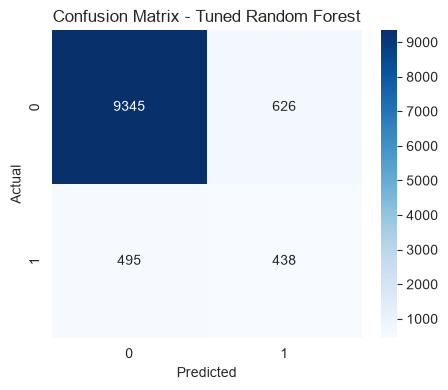

In [43]:
# Plot the confusion matrix as a heatmap so it is easy to read
confusion = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Cross-validation

**What is validation and why it matters:** Cross-validation splits the training data into several parts
(folds), trains on some folds and tests on the remaining one, and repeats so every fold is used for testing
once. We then average the scores. It gives a more reliable estimate than a single split and helps detect
overfitting.

In [44]:
# Cross-validation: test the tuned model on 5 different splits to check it is stable
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring="f1")
print("F1 score for each fold:", cv_scores.round(3))
print("Average F1 score:", round(cv_scores.mean(), 3))

F1 score for each fold: [0.411 0.412 0.429 0.437 0.415]
Average F1 score: 0.421


### Save the model, scaler and feature list
We save these three files so the Streamlit web app can load them and make predictions.

In [45]:
# Save the trained model (compressed to keep the file small for GitHub),
# the scaler, and the list of feature names
joblib.dump(best_model, "model.pkl", compress=3)
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X_selected.columns), "features.pkl")
print("Saved: model.pkl, scaler.pkl, features.pkl")

Saved: model.pkl, scaler.pkl, features.pkl


### Step 6 — Summary
- Split into train (80%) / test (20%), stratified to keep the class balance.
- Scaled the features with `StandardScaler`.
- Compared four models using precision, recall and F1 (not accuracy):

| Model | Precision | Recall | F1 |
|---|---|---|---|
| Logistic Regression | 0.21 | 0.67 | 0.32 |
| KNN | 0.76 | 0.23 | 0.35 |
| Decision Tree | 0.37 | 0.40 | 0.38 |
| Random Forest | 0.67 | 0.36 | 0.47 |

- **Random Forest was the best.** After GridSearchCV tuning (`max_depth=20`, `n_estimators=200`), it reached
  **precision ≈ 0.66 and recall ≈ 0.38** on the test set — both clearly above the required **0.3**.
- Cross-validation gave a stable average F1 of about **0.46**.
- Saved the final model, scaler, and feature list for deployment.

**Next step → Step 7: Deployment (Streamlit web app).**

## Step 7 — Deployment

The model is deployed as a simple **Streamlit web app** in the file `app.py`.

**What the app does:**
1. Loads the saved `model.pkl`, `scaler.pkl`, and `features.pkl`.
2. Shows input fields for the employee details (department, education, gender, recruitment channel,
   number of trainings, age, previous year rating, length of service, awards, average training score).
   The `region` column is not needed because it was dropped during feature selection.
3. Builds one row of features in the **exact same way as this notebook**: it creates the engineered
   features (`total_score`, `high_training_score`) and one-hot encodes the categories so the columns
   match the training columns.
4. Scales the row with the saved scaler and predicts with the saved model.
5. Shows whether the employee is likely to be promoted, together with the probability.

**How to run the app locally:**
```
pip install -r requirements.txt
streamlit run app.py
```
Keep `model.pkl`, `scaler.pkl`, and `features.pkl` in the same folder as `app.py`.

To get a public link, deploy the GitHub repository on **Streamlit Community Cloud** (share.streamlit.io).